# Customer Churn Analysis and Prediction

This notebook demonstrates how to analyze and predict customer churn using machine learning techniques.  

**Steps included:**
1. Data loading and exploration
2. Data preprocessing and feature engineering
3. Model building (Logistic Regression & Random Forest & Gradient Boosting)
4. Model evaluation using metrics like accuracy, ROC-AUC, and confusion matrix
5. Insights and recommendations
6. Customer Risk Segmentation

## 1) IMPORT LIBRARIES

In [15]:
# Data Manipulation
import pandas as pd  # for dataframes and CSV handling
import numpy as np   # for numerical operations


# Data Visualization
import matplotlib.pyplot as plt  # plotting
import seaborn as sns            # enhanced visualizations


# Machine Learning
from sklearn.model_selection import train_test_split   # splitting data
from sklearn.linear_model import LogisticRegression   # baseline ML model
from sklearn.ensemble import RandomForestClassifier  # more complex model
from sklearn.metrics import (                       # evaluation metrics
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

## 2) LOAD DATASET

In [17]:
# Load dataset
df = pd.read_csv(r"C:\Users\س\3D Objects\Telco_Cusomer_Churn.csv")
# Display first rows
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3) DATA CLEANING

In [3]:
# Check missing values
df.isnull().sum()

# Convert TotalCharges to numeric (some datasets have it as object)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing rows
df.dropna(inplace=True)

# Convert target variable to binary (Yes=1, No=0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


## 4) EXPLORATORY DATA ANALYSIS

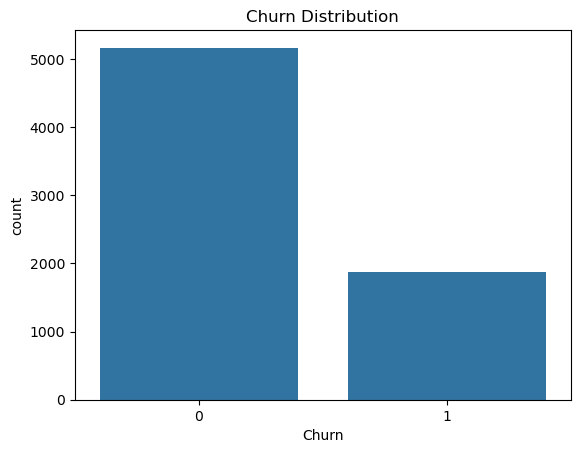

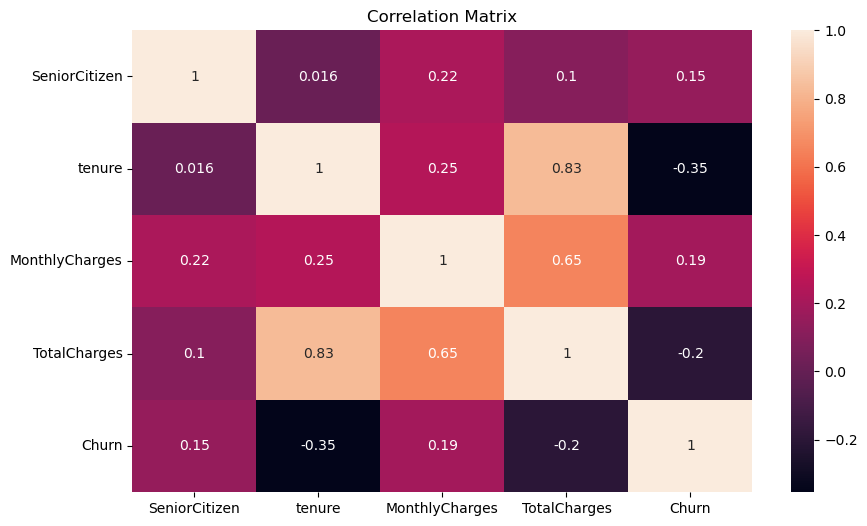

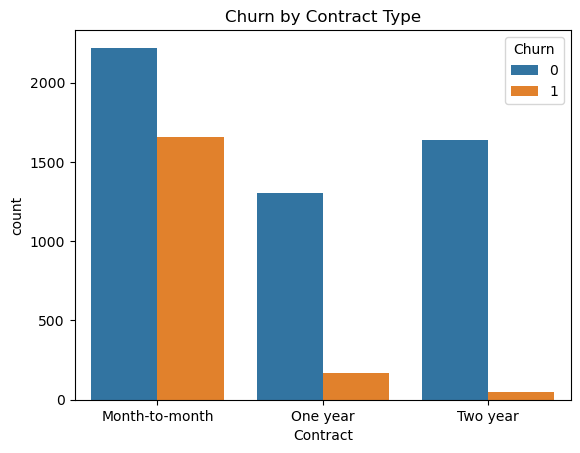

In [4]:
# Churn distribution
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# Correlation heatmap (numeric features only)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Churn by Contract Type
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

## 5)FEATURE ENGINEERING

In [5]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Convert categorical variables to dummy variables
X = pd.get_dummies(X, drop_first=True)


## 6) TRAIN / TEST SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 7) MODEL 1 — LOGISTIC REGRESSION

In [7]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7903340440653873
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.62      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



## 8) MODEL 2 — RANDOM FOREST

In [8]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7896233120113717
              precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



## 9) Model 3 _ Gradient Boosting

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

gb_probs = gb_model.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_auc_score

print("Gradient Boosting AUC:", roc_auc_score(y_test, gb_probs))


Gradient Boosting AUC: 0.834150830093544


## 10) MODEL COMPARISON (AUC)

In [10]:
# Compute probabilities
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:,1])
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
gb_auc = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1])

print("Logistic Regression AUC :", log_auc)
print("Random Forest AUC       :", rf_auc)
print("Gradient Boosting AUC   :", gb_auc)



Logistic Regression AUC : 0.8339916447085741
Random Forest AUC       : 0.8196921380538487
Gradient Boosting AUC   : 0.834150830093544


## Model Performance Summary

We evaluated three models using the **ROC-AUC metric**, which measures the model's ability to distinguish between churn and non-churn customers:

| Model                 | ROC-AUC Score |
|-----------------------|---------------|
| Logistic Regression   | 0.834         |
| Random Forest         | 0.820         |
| Gradient Boosting     | 0.834         |

### Observations:
1. **Logistic Regression** and **Gradient Boosting** have similar performance, with an AUC of ~0.83, indicating strong ability to discriminate churners from non-churners.
2. **Random Forest** has a slightly lower AUC (~0.82), but still performs well.
3. All models show **good predictive performance**, so they can reliably be used to identify customers at risk of churn.

## 11) AUC COMPARISON VISUALIZATION

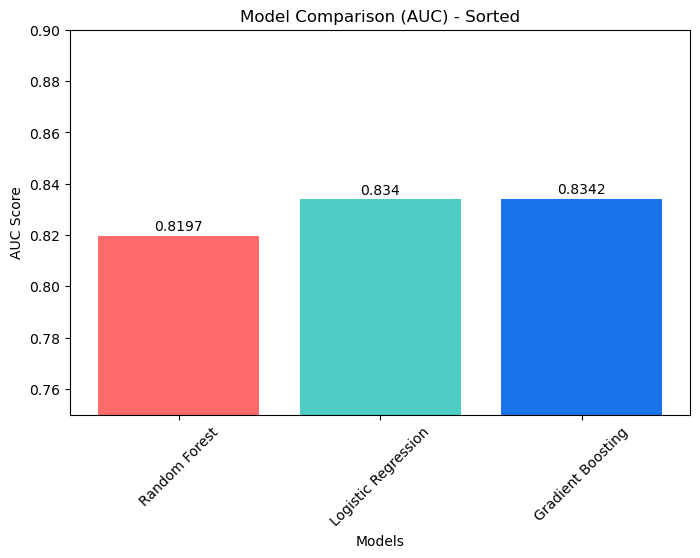

In [11]:

models = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
auc_scores = [log_auc, rf_auc, gb_auc]

# Sort values (ascending = croissant)
sorted_indices = np.argsort(auc_scores)
models_sorted = np.array(models)[sorted_indices]
auc_sorted = np.array(auc_scores)[sorted_indices]

# Colors
colors = ["#FF6B6B", "#4ECDC4", "#1A73E8"]

plt.figure(figsize=(8,5))
bars = plt.bar(models_sorted, auc_sorted, color=colors)

plt.xlabel("Models")
plt.ylabel("AUC Score")
plt.title("Model Comparison (AUC) - Sorted")
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, 
             yval + 0.002, 
             round(yval, 4), 
             ha='center')

plt.ylim(0.75, 0.90)
plt.show()

In [12]:
best_model = gb_model

## 12) PREDICT CHURN PROBABILITY FOR ALL CUSTOMERS

In [13]:
# Generate churn probability for entire dataset
df["Churn_Probability"] = best_model.predict_proba(X)[:,1]


## 13) CUSTOMER RISK SEGMENTATION

In [14]:

importance = pd.Series(
    gb_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

importance.head(10)

# ==========================================
# 8️⃣ PREDICT CHURN PROBABILITY FOR ALL CUSTOMERS
# ==========================================
# Ensure same features as training
X_full = df.drop("Churn", axis=1)
X_full = pd.get_dummies(X_full, drop_first=True)
X_full = X_full[X_train.columns]  # Fix feature mismatch

# Predict probabilities
df["Churn_Prob_Logistic"] = log_model.predict_proba(X_full)[:,1]
df["Churn_Prob_RF"] = rf_model.predict_proba(X_full)[:,1]
df["Churn_Prob_GB"] = gb_model.predict_proba(X_full)[:,1]

def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Medium Risk"
    else:
        return "High Risk"

# Apply to all models
df["Risk_Logistic"] = df["Churn_Prob_Logistic"].apply(risk_category)
df["Risk_RF"] = df["Churn_Prob_RF"].apply(risk_category)
df["Risk_GB"] = df["Churn_Prob_GB"].apply(risk_category)

# Check results
df[[
    "Churn_Prob_Logistic", "Risk_Logistic",
    "Churn_Prob_RF", "Risk_RF",
    "Churn_Prob_GB", "Risk_GB"
]].head()

# Count distribution
print("Logistic Regression Risk Distribution:\n", df["Risk_Logistic"].value_counts())
print("Random Forest Risk Distribution:\n", df["Risk_RF"].value_counts())
print("Gradient Boosting Risk Distribution:\n", df["Risk_GB"].value_counts())

Logistic Regression Risk Distribution:
 Risk_Logistic
Low Risk       4385
Medium Risk    1513
High Risk      1134
Name: count, dtype: int64
Random Forest Risk Distribution:
 Risk_RF
Low Risk       4983
High Risk      1657
Medium Risk     392
Name: count, dtype: int64
Gradient Boosting Risk Distribution:
 Risk_GB
Low Risk       4437
Medium Risk    1692
High Risk       903
Name: count, dtype: int64


## Conclusion and Insights

1. **Model Comparison:**
- **Logistic Regression** predicts most customers as Low Risk (4385), with a moderate number as Medium Risk (1513) and High Risk (1134).  
- **Random Forest** classifies a higher number of customers as Low Risk (4983), fewer as Medium Risk (392), but more as High Risk (1657).  
- **Gradient Boosting** provides a more balanced distribution, with 4437 Low Risk, 1692 Medium Risk, and 903 High Risk.

2. **Observations:**
- Random Forest tends to be more **conservative**, assigning more customers to Low or High Risk categories and fewer in Medium Risk.  
- Logistic Regression and Gradient Boosting produce a more **gradual risk spread**, which may help identify medium-risk customers for proactive retention.  
- All models clearly identify a portion of customers at **high risk of churn**, which can be targeted for retention strategies.

3. **Business Implications:**
- Customers labeled **High Risk** should be prioritized for retention campaigns.  
- Medium Risk customers, especially in Logistic Regression and Gradient Boosting, represent an **opportunity to intervene early**.  
- Low Risk customers can be **monitored periodically** but may not need immediate action.

4. **Recommendation:**
- Depending on the business strategy, **Gradient Boosting** may offer the best balance between identifying Medium and High Risk customers, while **Random Forest** is better if the goal is to identify the extreme ends of risk quickly.  
- Combining model predictions or using **ensemble strategies** could further improve churn risk assessment.

---
